# Experiment 3, fast version — 200k steps

Experiment 1a and its follow-ups established the ingredients; this notebook puts them together on the
plan's Experiment 3 problem and tries to **learn** a good structure: separate subnetworks and low loss.

**Fast version.** The same code, rules, and problem as `experiment_3.ipynb`, at 200k steps instead of
1M and 100 snapshots instead of 250, so a run takes tens of seconds. Runs are cached under their own
prefix, and the repo's persistent JAX compilation cache is switched on, so re-executing an unchanged
notebook skips the compiles as well.

**Problem.** Stationary 8-task multi-GEOFF (`phd/jax_core/tasks/multi_geoff.py`): eight independent
GEOFF teachers, each with 20 inputs and 10 outputs, plus $N(0, 1)$ observation noise. Inputs and
outputs are laid out task-major, and the loss is a plain sum of per-output squared errors, so nothing
about the grouping leaks through the loss. Training is online, one fresh sample per step. Per-output
MSE is 1.0 for an optimal predictor and 2.0 for the mean predictor; the fraction of variance
explained (FVE) is $1 - (\text{MSE} - 1)$.

**Network.** 64 LTU hidden units — a step function forward, a sigmoid-derivative surrogate backward —
and a budget of `BUDGET` connections, biases not counted. Output units read `[inputs | hidden | 1]`
and hidden units `[inputs | 1]`, so an output unit's skip connections, hidden connections, and bias
all live in one row of one matrix, which is what Autostep's per-unit normalizer (a row sum) needs.
Connectivity is a 0/1 mask over that layout. The network, the restructuring rules, and the metrics
are in `dynamic_skip_mlp.py`, with tests in `../tests/test_dynamic_skip_mlp.py`.

**Initial structure** (the plan's): each hidden unit gets exactly one outgoing connection, to a random
output unit; the rest of the budget is split evenly over all hidden and output units as random input
connections, so output units get input→output skip connections. Every input weight starts uniform in
$(-w_0, w_0)$ with $w_0$ = `INIT_W_INPUT`; hidden→output weights and biases start at 0.

**Learning rules**, from the 1a follow-ups:

* Autostep variant B (normalize by the squared value of each weight's source unit) on every
  connection, starting at step-size `INIT_LR`, except the bias columns, which start at
  `INIT_BIAS_LR`, so the output biases absorb the target means before anything else can act as a
  bias substitute.
* **Fixed ±1 feedback.** On the backward pass each hidden→output connection is replaced by a fixed
  random ±1, drawn once per run. The input layer therefore learns from step 0 even though `w2` is 0,
  and its learning signal does not depend on what `w2` happens to be. The forward pass and `w2`'s
  own gradient are the ordinary ones.
* Subgradient L1 with coefficient `L1_COEFF` on every connection but the biases, inside the gradient
  Autostep adapts on.

**Runs.**

* **3a — fixed connectivity:** the initial structure held fixed.
* **3b — learned connectivity:** an input connection is pruned the step its weight changes sign, and
  replaced one-for-one: a destination uniformly over all hidden and output units, then an input that
  destination is not yet connected to. The new connection is initialized like an initial one.
  Hidden→output connections are never pruned, so each hidden unit keeps its one output for the run.
* **3c — fixed in-degree, then backpropagation:** every pruned connection is replaced on the *same*
  unit with a new random source, so each hidden and output unit keeps its number of incoming
  connections for the whole run. For the first `FEEDBACK_STEPS` steps the error comes through the
  fixed feedback as in 3b; after that the hidden→output connections behave like ordinary
  connections: the hidden units' error comes through the actual weights, an output unit's
  replacement may draw a hidden unit as its source, and those connections are prunable like input
  connections. Each hidden unit's initial output connection stays protected.
* **Three references:** block-sparse (each hidden unit fully connected to its own task's inputs and
  outputs — the good structure), dense, and a linear baseline: every same-task input→output skip
  connection and nothing else, with no cross-task connection even where the budget would allow one.
  When the budget holds all same-task pairs it is *block-sparse linear*; when it does not, a random
  same-task subset of budget size is used and it is called *sparse block-sparse linear*. The
  structures cell prints which case applies and how much of the budget is used. All references use
  the same optimizer settings and L1, but the ordinary initialization and ordinary backpropagation.

**What to read.** The learning curves against the references; whether the connection count holds the
budget; connectivity separation, signal separation, and hidden-input purity over time (chance is
1/8, block-sparse is 1); the step-size and weight quantiles of same-task versus cross-task input
connections; and the turnover — how many input connections change sign per step, split the same way.

In [1]:
import json
import os
import sys
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from phd.jax_core.tasks.multi_geoff import MultiGEOFFTask
from omegaconf import OmegaConf

from phd.jax_core.utils import configure_jax, stack_pytrees
from phd.research_utils.analysis.analysis_utils import get_color_palette

NOTEBOOK_DIR = os.path.abspath('.')
if NOTEBOOK_DIR not in sys.path:      # make the sibling modules importable
    sys.path.insert(0, NOTEBOOK_DIR)

from masked_mlp import slot_ids
from dynamic_skip_mlp import (
    NO_TASK, DynamicAutostepMLP, block_sparse_skip_masks, dense_skip_masks, group_quantiles,
    initial_structure, n_connections, random_feedback, structure_metrics, task_labels,
)

# The repo's JAX setup: a persistent compilation cache in /tmp/jax_cache, so re-executing an unchanged
# notebook skips every compile.
configure_jax(OmegaConf.create({'device': None}))

sns.set_theme('notebook', 'white')
%matplotlib inline

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an 

JAX device not specified, using default: cuda:0


## Configuration

In [2]:
# --- Problem (stationary 8-task multi-GEOFF) ---
N_TASKS = 8
N_FEATURES_PER_TASK = 20
N_OUTPUTS_PER_TASK = 10
NOISE_STD = 1.0

# --- Network ---
N_HIDDEN = 64
ACTIVATION = 'ltu'
BUDGET = 1920                    # connections, biases not counted: block-sparse's count at 64 hidden units

# --- Optimizer ---
INIT_LR = 1e-8                   # starting step-size of every connection
INIT_BIAS_LR = 2 ** -4           # starting step-size of the bias columns
INIT_W_INPUT = 1e-8              # input->hidden and skip weights start uniform in (-INIT_W_INPUT, INIT_W_INPUT)
META_LR = 0.02
L1_COEFF = 0.01                 # subgradient L1 inside the gradient Autostep adapts on; biases exempt
GEN_CAP = 512                    # connections generated per step at most; the deficit audit checks it
FEEDBACK_STEPS = 10_000          # 3c: fixed +-1 feedback for this many steps, then plain backpropagation

# --- Training and recording ---
NUM_STEPS = 200_000
N_SEEDS = 10                     # vmapped into one scan; one teacher, one structure and one init each
N_SNAPSHOTS = 100                # structure snapshots per run; per-step scalars are averaged per block
QUANTILES = (0.1, 0.25, 0.5, 0.75, 0.9)
BASE_SEED = 0
RERUN = False                    # True recomputes every run instead of loading its cached .npz
DATA_DIR = os.path.join(NOTEBOOK_DIR, 'data')

# --- Derived ---
N_FEATURES = N_TASKS * N_FEATURES_PER_TASK
N_OUTPUTS = N_TASKS * N_OUTPUTS_PER_TASK
INPUT_TASK_IDS = slot_ids(N_TASKS, N_FEATURES_PER_TASK)
OUTPUT_TASK_IDS = slot_ids(N_TASKS, N_OUTPUTS_PER_TASK)
IRREDUCIBLE_MSE = NOISE_STD ** 2         # per-output MSE of an optimal predictor
BASELINE_MSE = IRREDUCIBLE_MSE + 1.0     # the mean predictor sits 1 above it
VIEW_NAMES = ('hidden $\\leftarrow$ inputs', 'outputs $\\leftarrow$ inputs (skips)',
              'outputs $\\leftarrow$ hidden')      # the three kinds of connection, in the module's order
GROUP_NAMES = ('same task', 'cross task')
GROUP_COLORS = ('#3b6fb0', '#c0392b')
os.makedirs(DATA_DIR, exist_ok=True)

## Structures

| structure | used by | shape |
|---|---|---|
| `exp3` | 3a and 3b | one random output per hidden unit, then the rest of the budget split evenly over all hidden and output units as random input connections (skips for the output units); redrawn per seed |
| `block_sparse` | reference | each hidden unit fully connected to its own task's inputs and outputs |
| `dense` | reference | fully connected, no skip connections |
| `block_sparse_linear` | reference | every same-task input→output skip connection and nothing else; the hidden units are left disconnected. A random same-task subset if the budget is below their count, and never a cross-task connection |

Every structure carries a bias on every hidden and output unit; biases are not part of the budget.
A structure function returns the masks, the feedback signs (None for the references), and each
hidden unit's task id — the task of the output it feeds, or `NO_TASK` for the dense reference, whose
hidden units belong to no task and so get no same-task / cross-task labels.

In [3]:
# The references spend the same budget: block-sparse at 30 connections per hidden unit (its task's 20
# inputs and 10 outputs), dense at N_FEATURES + N_OUTPUTS per hidden unit.
BLOCK_SPARSE_HIDDEN = BUDGET // (N_FEATURES_PER_TASK + N_OUTPUTS_PER_TASK)
DENSE_HIDDEN = BUDGET // (N_FEATURES + N_OUTPUTS)
assert BLOCK_SPARSE_HIDDEN * (N_FEATURES_PER_TASK + N_OUTPUTS_PER_TASK) == BUDGET, BUDGET
assert BLOCK_SPARSE_HIDDEN % N_TASKS == 0 and DENSE_HIDDEN * (N_FEATURES + N_OUTPUTS) == BUDGET, BUDGET


def exp3_structure(key):
    """One draw of the Experiment 3 initialization: masks, feedback signs, hidden-unit task ids."""
    structure_key, feedback_key = jax.random.split(key)
    masks, hidden_output = initial_structure(N_FEATURES, N_HIDDEN, N_OUTPUTS, BUDGET, structure_key)
    return masks, random_feedback(masks, feedback_key), OUTPUT_TASK_IDS[hidden_output]


def block_sparse_structure(key):
    masks, hidden_task_ids = block_sparse_skip_masks(
        N_TASKS, N_FEATURES_PER_TASK, N_OUTPUTS_PER_TASK, BLOCK_SPARSE_HIDDEN)
    return masks, None, hidden_task_ids


def dense_structure(key):
    masks = dense_skip_masks(N_FEATURES, DENSE_HIDDEN, N_OUTPUTS)
    return masks, None, jnp.full((DENSE_HIDDEN,), NO_TASK)


N_SAME_TASK_SKIPS = N_TASKS * N_FEATURES_PER_TASK * N_OUTPUTS_PER_TASK
LINEAR_LABEL = ('block-sparse linear (reference)' if BUDGET >= N_SAME_TASK_SKIPS
                else 'sparse block-sparse linear (reference)')


def block_sparse_linear_structure(key):
    """Every same-task input->output skip connection and nothing else: the hidden units stay
    disconnected, and no cross-task connection is added even when the budget would allow one. If the
    budget cannot hold all `N_SAME_TASK_SKIPS` of them, a random same-task subset of budget size is
    drawn per seed."""
    same = (OUTPUT_TASK_IDS[:, None] == INPUT_TASK_IDS[None, :]).astype(jnp.float32)
    if BUDGET < N_SAME_TASK_SKIPS:
        # Rank the same-task positions in a random order and keep the first BUDGET of them.
        noise = jnp.where(same > 0, jax.random.uniform(key, same.shape), jnp.inf).reshape(-1)
        rank = jnp.argsort(jnp.argsort(noise)).reshape(same.shape)
        same = same * (rank < BUDGET)
    masks = {'w1': jnp.zeros((N_HIDDEN, N_FEATURES + 1)).at[:, -1].set(1.0),
             'w2': jnp.concatenate([same, jnp.zeros((N_OUTPUTS, N_HIDDEN)), jnp.ones((N_OUTPUTS, 1))],
                                   axis=1)}
    return masks, None, jnp.full((N_HIDDEN,), NO_TASK)


for name, structure in (('exp3', exp3_structure), ('block-sparse', block_sparse_structure),
                        ('dense', dense_structure), ('linear', block_sparse_linear_structure)):
    masks, _, _ = structure(jax.random.PRNGKey(BASE_SEED))
    n_hidden, n_features = masks['w1'].shape[0], masks['w1'].shape[1] - 1
    print(f'{name:13s} {n_connections(masks):5d} connections   {n_hidden:3d} hidden units   '
          f'{float(masks["w1"][:, :n_features].sum()) / n_hidden:5.1f} inputs per hidden unit   '
          f'{float(masks["w2"][:, :n_features].sum()) / N_OUTPUTS:5.1f} skips per output unit')

used = min(BUDGET, N_SAME_TASK_SKIPS)
print(f'\nlinear baseline: {LINEAR_LABEL.split(" (")[0]}, {used} of {BUDGET} connections used'
      + (f'; {BUDGET - used} left unused rather than spent on cross-task connections'
         if BUDGET > N_SAME_TASK_SKIPS else
         f'; the budget is below the {N_SAME_TASK_SKIPS} same-task pairs, so a random subset is drawn'
         if BUDGET < N_SAME_TASK_SKIPS else '; exactly the same-task pairs'))

exp3           1920 connections    64 hidden units    12.9 inputs per hidden unit    12.9 skips per output unit


block-sparse   1920 connections    64 hidden units    20.0 inputs per hidden unit     0.0 skips per output unit


dense          1920 connections     8 hidden units   160.0 inputs per hidden unit     0.0 skips per output unit


linear         1600 connections    64 hidden units     0.0 inputs per hidden unit    20.0 skips per output unit

linear baseline: block-sparse linear, 1600 of 1920 connections used; 320 left unused rather than spent on cross-task connections


## Training

A nested scan: the inner scan runs one block of steps and emits only per-step scalars (loss, sign
changes, prunes, generations, deficit), the outer scan takes one structure snapshot per block and
averages the block's scalars, so a run costs almost nothing to record. Snapshots are taken at the
start of each block plus once at the end, so step 0 is in every structure figure.

Same-task / cross-task labels are attached to *positions*, not connections: every possible input
connection is same-task or cross-task by construction, and the current masks decide which of them
count. That is what lets the crossing counts and the quantile bands be split by group while the
connectivity changes underneath them.

Runs are cached as `.npz` files in `data/` under their name, together with the settings they were
run with, so re-executing the notebook loads them unless a setting changed; `RERUN` forces a recompute.

In [4]:
def make_learner(structure, key, *, restructure=False, reference=False, **learner_kwargs):
    """The learner for one seed. References use the ordinary init and plain backpropagation;
    `learner_kwargs` go to `DynamicAutostepMLP.init` (3c passes `feedback_steps`, `hidden_sources`)."""
    structure_key, weight_key = jax.random.split(key)
    masks, feedback, hidden_task_ids = structure(structure_key)
    labels = task_labels({k: jnp.ones_like(m) for k, m in masks.items()}, hidden_task_ids,
                         INPUT_TASK_IDS, OUTPUT_TASK_IDS)
    return DynamicAutostepMLP.init(
        masks, META_LR, weight_key, init_lr=INIT_LR, bias_init_lr=INIT_BIAS_LR,
        input_weight_scale=INIT_W_INPUT, l1=L1_COEFF, activation=ACTIVATION,
        feedback=None if reference else feedback,
        weight_init='lecun' if reference else 'small_uniform',
        restructure=restructure, gen_cap=GEN_CAP, labels=labels, **learner_kwargs)


def snapshot(learner):
    """Structure metrics, plus step-size and |w| quantiles of the active connections, shaped
    (view, group, quantile) with the views of `VIEW_NAMES`."""
    model = learner.model
    return {**structure_metrics(model, INPUT_TASK_IDS, OUTPUT_TASK_IDS, n_tasks=N_TASKS),
            'alpha_q': group_quantiles(learner.alpha, learner.labels, model.masks, QUANTILES),
            'absw_q': group_quantiles({k: jnp.abs(w) for k, w in model.weights.items()},
                                      learner.labels, model.masks, QUANTILES)}


RATE_KEYS = ('n_crossed', 'n_crossed_useful', 'n_crossed_useless', 'n_crossed_hidden_out',
             'n_pruned', 'n_generated')


def train(learner, task):
    """`NUM_STEPS` of online training: per-block means of the per-step scalars, and `N_SNAPSHOTS` + 1
    structure snapshots, the first at step 0."""
    def one_step(carry, _):
        learner, task = carry
        task, (x, y) = task.generate_batch(1)              # online: one sample per step
        learner, info = learner.step(x[0], y[0])
        return (learner, task), info

    def block(carry, _):
        snap = snapshot(carry[0])                          # start-of-block, so step 0 is recorded
        carry, info = jax.lax.scan(one_step, carry, length=NUM_STEPS // N_SNAPSHOTS)
        stats = {'mse': info['loss'].mean() / N_OUTPUTS,
                 **{k: info[k].mean() for k in RATE_KEYS},              # per step
                 'deficit': info['deficit'].mean(), 'max_deficit': info['deficit'].max()}
        return carry, (stats, snap)

    carry, (stats, snaps) = jax.lax.scan(block, (learner, task), length=N_SNAPSHOTS)
    snaps = jax.tree.map(lambda s, final: jnp.concatenate([s, final[None]]), snaps,
                         snapshot(carry[0]))
    return stats, snaps


def run_settings():
    """The settings a cached run has to match to be reused."""
    return json.dumps(dict(
        N_TASKS=N_TASKS, N_FEATURES_PER_TASK=N_FEATURES_PER_TASK, N_OUTPUTS_PER_TASK=N_OUTPUTS_PER_TASK,
        NOISE_STD=NOISE_STD, N_HIDDEN=N_HIDDEN, ACTIVATION=ACTIVATION, BUDGET=BUDGET, INIT_LR=INIT_LR,
        INIT_BIAS_LR=INIT_BIAS_LR, INIT_W_INPUT=INIT_W_INPUT, META_LR=META_LR, L1_COEFF=L1_COEFF,
        GEN_CAP=GEN_CAP, FEEDBACK_STEPS=FEEDBACK_STEPS,
        NUM_STEPS=NUM_STEPS, N_SEEDS=N_SEEDS, N_SNAPSHOTS=N_SNAPSHOTS, QUANTILES=list(QUANTILES),
        BASE_SEED=BASE_SEED), sort_keys=True)


def run(name, structure, **kwargs):
    """Train `N_SEEDS` seeds of one configuration, vmapped into one scan; cached by `name`."""
    path = os.path.join(DATA_DIR, f'exp3_fast_{name}.npz')
    settings = run_settings()
    if os.path.exists(path) and not RERUN:
        with np.load(path) as data:
            if str(data['settings']) == settings:
                return {k: data[k] for k in data.files if k != 'settings'}
        print(f'{name}: the cached run used different settings, recomputing')

    tasks = stack_pytrees([                                # the task takes an int seed, not a key
        MultiGEOFFTask(N_TASKS, n_features_per_task=N_FEATURES_PER_TASK,
                       n_outputs_per_task=N_OUTPUTS_PER_TASK, noise_std=NOISE_STD,
                       seed=BASE_SEED + s)
        for s in range(N_SEEDS)])
    keys = jax.random.split(jax.random.PRNGKey(BASE_SEED), N_SEEDS)
    start = time.time()
    stats, snaps = jax.jit(jax.vmap(
        lambda key, task: train(make_learner(structure, key, **kwargs), task)))(keys, tasks)
    jax.block_until_ready(stats)
    print(f'{name}: {time.time() - start:.0f} s')

    block_len = NUM_STEPS // N_SNAPSHOTS
    result = {'steps': np.arange(1, N_SNAPSHOTS + 1) * block_len,
              'snap_steps': np.arange(N_SNAPSHOTS + 1) * block_len,
              **{k: np.asarray(v) for k, v in stats.items()},
              **{k: np.asarray(v) for k, v in snaps.items()}}
    np.savez(path, settings=settings, **result)
    return result

In [5]:
LABEL_3C = f'3c — fixed in-degree, backprop after {FEEDBACK_STEPS // 1000}k steps'

runs = {
    'block-sparse (reference)': run('block_sparse', block_sparse_structure, reference=True),
    'dense (reference)': run('dense', dense_structure, reference=True),
    LINEAR_LABEL: run('linear', block_sparse_linear_structure, reference=True),
    '3a — fixed connectivity': run('3a_fixed', exp3_structure),
    '3b — learned connectivity': run('3b_learned', exp3_structure, restructure=True),
    LABEL_3C: run('3c_fixed_indegree', exp3_structure, restructure=True,
                  regeneration='same_destination', feedback_steps=FEEDBACK_STEPS,
                  hidden_sources=True),
}
COLORS = dict(zip(runs, get_color_palette(n=len(runs))))

2026-09-10 20:42:13.625940: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-09-10 20:42:13.626008: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


linear: 26 s


## Results

### Learning curves

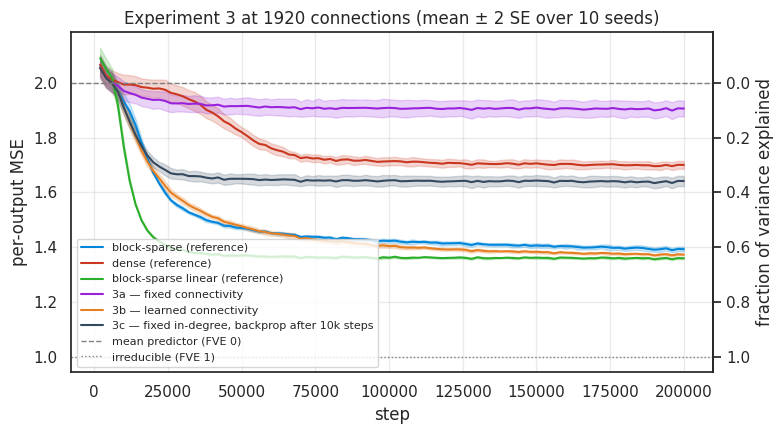

In [6]:
def plot_curves(runs):
    """Per-output MSE per run, mean ± 2 standard errors over seeds; the right axis reads FVE."""
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for label, res in runs.items():
        mean, sem = res['mse'].mean(0), res['mse'].std(0) / np.sqrt(N_SEEDS)
        ax.plot(res['steps'], mean, color=COLORS[label], label=label)
        ax.fill_between(res['steps'], mean - 2 * sem, mean + 2 * sem, color=COLORS[label], alpha=0.2)
    ax.axhline(BASELINE_MSE, ls='--', c='gray', lw=1, label='mean predictor (FVE 0)')
    ax.axhline(IRREDUCIBLE_MSE, ls=':', c='gray', lw=1, label='irreducible (FVE 1)')
    ax.secondary_yaxis('right', functions=(lambda m: 1.0 - (m - IRREDUCIBLE_MSE),
                                           lambda f: IRREDUCIBLE_MSE + 1.0 - f)
                       ).set_ylabel('fraction of variance explained')
    ax.set_xlabel('step')
    ax.set_ylabel('per-output MSE')
    ax.set_title(f'Experiment 3 at {BUDGET} connections (mean ± 2 SE over {N_SEEDS} seeds)')
    ax.grid(alpha=0.4)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


plot_curves(runs)

### Did the budget hold?

Before reading anything else: 3b's connection count must stay at the budget. It is exactly
`BUDGET - deficit` at every step, so a deficit that does not sit near zero means `GEN_CAP` saturated
or proposals kept colliding, and the run trained a smaller network than intended. The crossing rate
is the same quantity for every run — in 3b every crossing is a prune, in the others it is only
counted.

In [7]:
def final(res, key, tail=0.1):
    """Mean of a per-block or per-snapshot series over the last `tail` of the run, over seeds."""
    values = np.asarray(res[key], dtype=np.float64)
    tail_values = values[:, -max(1, int(tail * values.shape[1])):]
    return float(np.nanmean(tail_values)) if np.isfinite(tail_values).any() else float("nan")


width = max(len(label) for label in runs)
print('final 10% of the run, per step where a rate')
for label, res in runs.items():
    print(f'  {label:<{width}}   connections {final(res, "n_connections"):7.1f} / {BUDGET}   '
          f'deficit: mean {res["deficit"].mean():6.2f}, worst step {res["max_deficit"].max():5.0f}   '
          f'sign changes {final(res, "n_crossed"):7.2f} '
          f'(same task {final(res, "n_crossed_useful"):6.2f}, cross task {final(res, "n_crossed_useless"):6.2f})   '
          f'pruned {final(res, "n_pruned"):6.2f}   of which hidden→output {final(res, "n_crossed_hidden_out"):5.2f}')

final 10% of the run, per step where a rate
  block-sparse (reference)                         connections  1920.0 / 1920   deficit: mean   0.00, worst step     0   sign changes   16.24 (same task  16.24, cross task   0.00)   pruned   0.00   of which hidden→output  0.00
  dense (reference)                                connections  1920.0 / 1920   deficit: mean   0.00, worst step     0   sign changes    7.50 (same task   0.00, cross task   0.00)   pruned   0.00   of which hidden→output  0.00
  block-sparse linear (reference)                  connections  1600.0 / 1920   deficit: mean   0.00, worst step     0   sign changes    0.86 (same task   0.86, cross task   0.00)   pruned   0.00   of which hidden→output  0.00
  3a — fixed connectivity                          connections  1920.0 / 1920   deficit: mean   0.00, worst step     0   sign changes   18.67 (same task   0.49, cross task  18.17)   pruned   0.00   of which hidden→output  0.00
  3b — learned connectivity                     

### Structure over time

Does restructuring walk the network toward one subnetwork per task? Connectivity separation counts
paths from each output back to the inputs and asks what fraction land on its own subtask; signal
separation weights each path by the product of its weights; hidden-input purity looks at the hidden
layer alone, so it separates "the outputs happen to read clean paths" from "the hidden units have
specialized". Chance is 1/8 for all three, block-sparse is 1. In 3a the two connectivity-only metrics
are flat by construction; signal separation is the one line there that says anything about training.

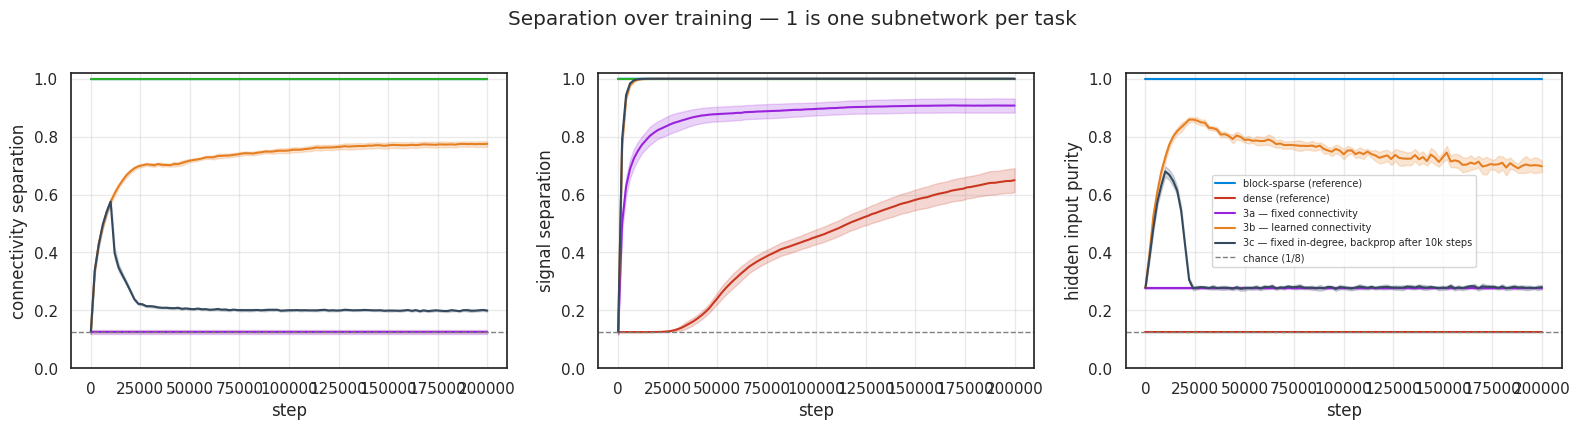

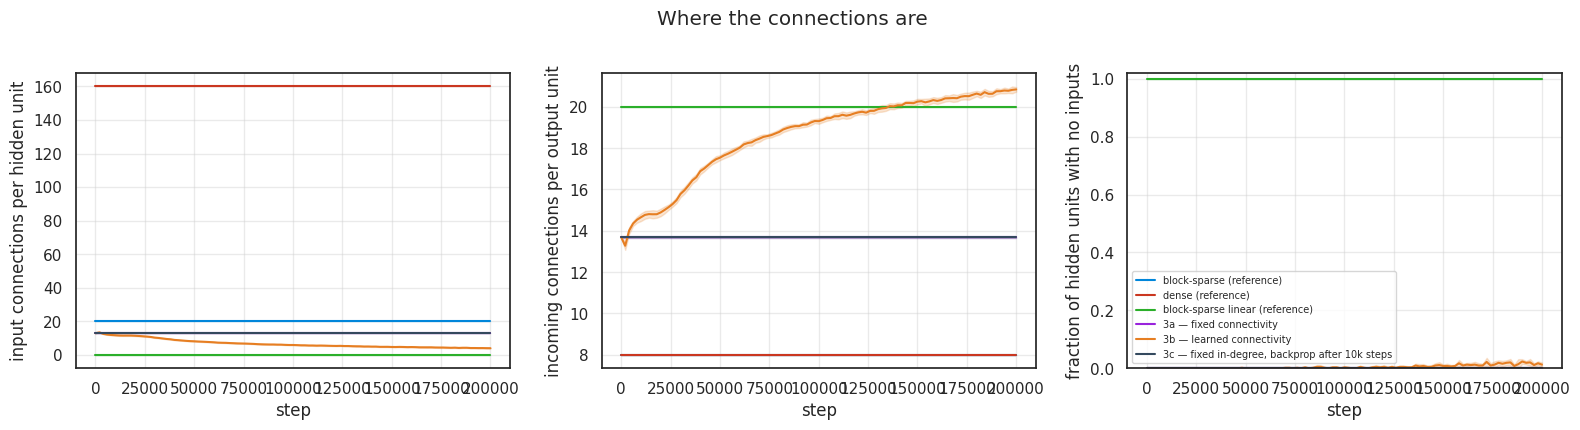

In [8]:
def plot_snapshot_metric(runs, key, ylabel, ax, hline=None, hline_label=None, ylim=None):
    """Mean over seeds ± 2 standard errors of a per-snapshot metric, one line per run."""
    for label, res in runs.items():
        values = np.asarray(res[key], dtype=np.float64)
        if not np.isfinite(values).any():                   # undefined for this structure
            continue
        mean, sem = np.nanmean(values, 0), np.nanstd(values, 0) / np.sqrt(N_SEEDS)
        ax.plot(res['snap_steps'], mean, color=COLORS[label], label=label)
        ax.fill_between(res['snap_steps'], mean - 2 * sem, mean + 2 * sem, color=COLORS[label],
                        alpha=0.2)
    if hline is not None:
        ax.axhline(hline, ls='--', c='gray', lw=1, label=hline_label)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xlabel('step')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.4)


fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, (key, ylabel) in zip(axes, [('connectivity_separation', 'connectivity separation'),
                                    ('signal_separation', 'signal separation'),
                                    ('hidden_input_purity', 'hidden input purity')]):
    plot_snapshot_metric(runs, key, ylabel, ax, hline=1.0 / N_TASKS,
                         hline_label=f'chance (1/{N_TASKS})', ylim=(0, 1.02))
axes[-1].legend(fontsize=7, loc='best')
fig.suptitle('Separation over training — 1 is one subnetwork per task', y=1.02)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
plot_snapshot_metric(runs, 'hidden_incoming', 'input connections per hidden unit', axes[0])
plot_snapshot_metric(runs, 'output_incoming', 'incoming connections per output unit', axes[1])
plot_snapshot_metric(runs, 'dead_hidden_fraction', 'fraction of hidden units with no inputs',
                     axes[2], ylim=(0, 1.02))
axes[-1].legend(fontsize=7, loc='best')
fig.suptitle('Where the connections are', y=1.02)
fig.tight_layout()
plt.show()

### Step-sizes and weights of same-task vs. cross-task connections

The Experiment 1a view, as a distribution rather than individual traces, because in 3b the set of
connections changes underneath: median and inter-quantile bands over the *currently active*
connections of each kind and group, quantiles averaged over seeds. Blue should climb off the
initial step-size and red should stay near it. The third column holds the hidden→output
connections; in 3a and 3b those are only the protected same-task ones, so it has no red there. The
dense reference has no labels and is skipped.

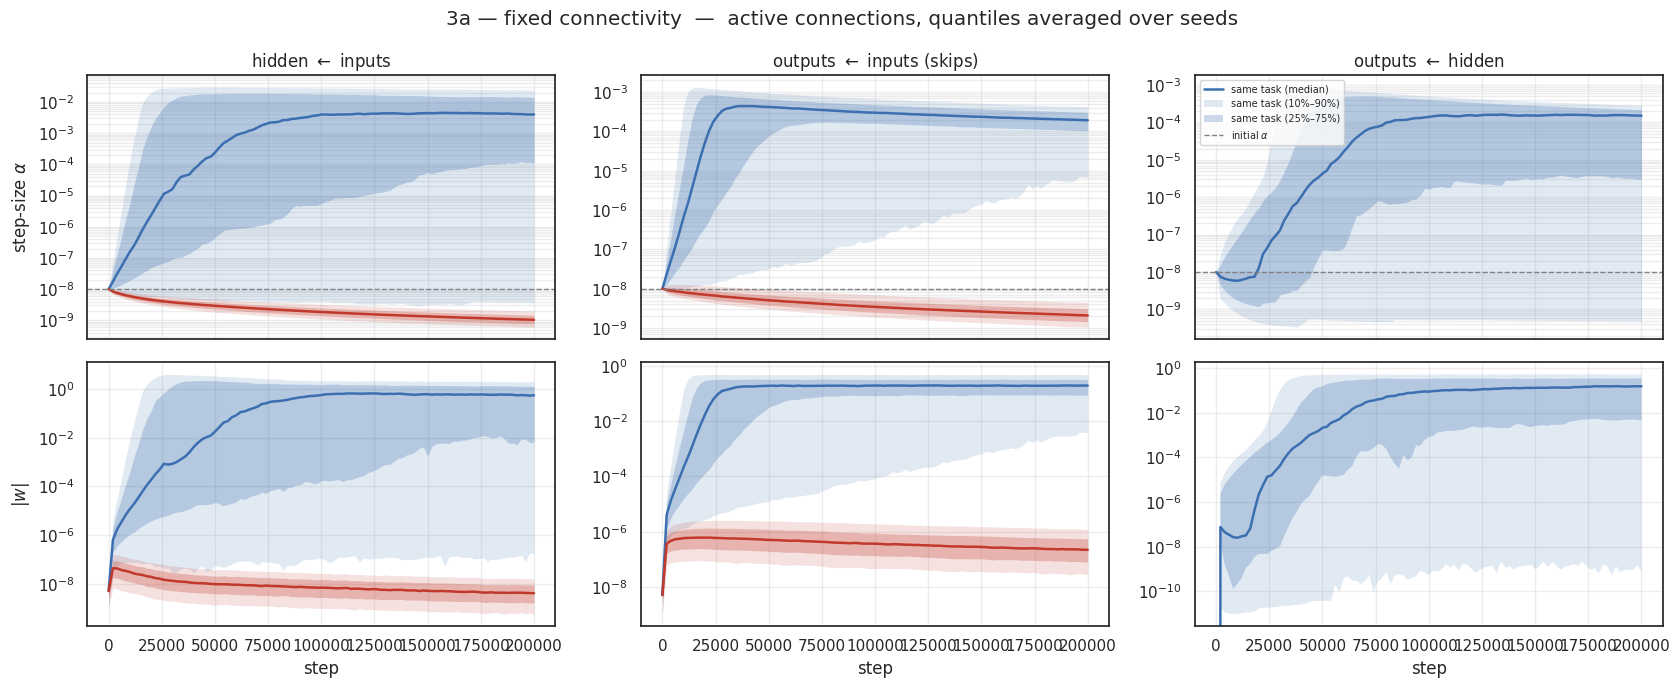

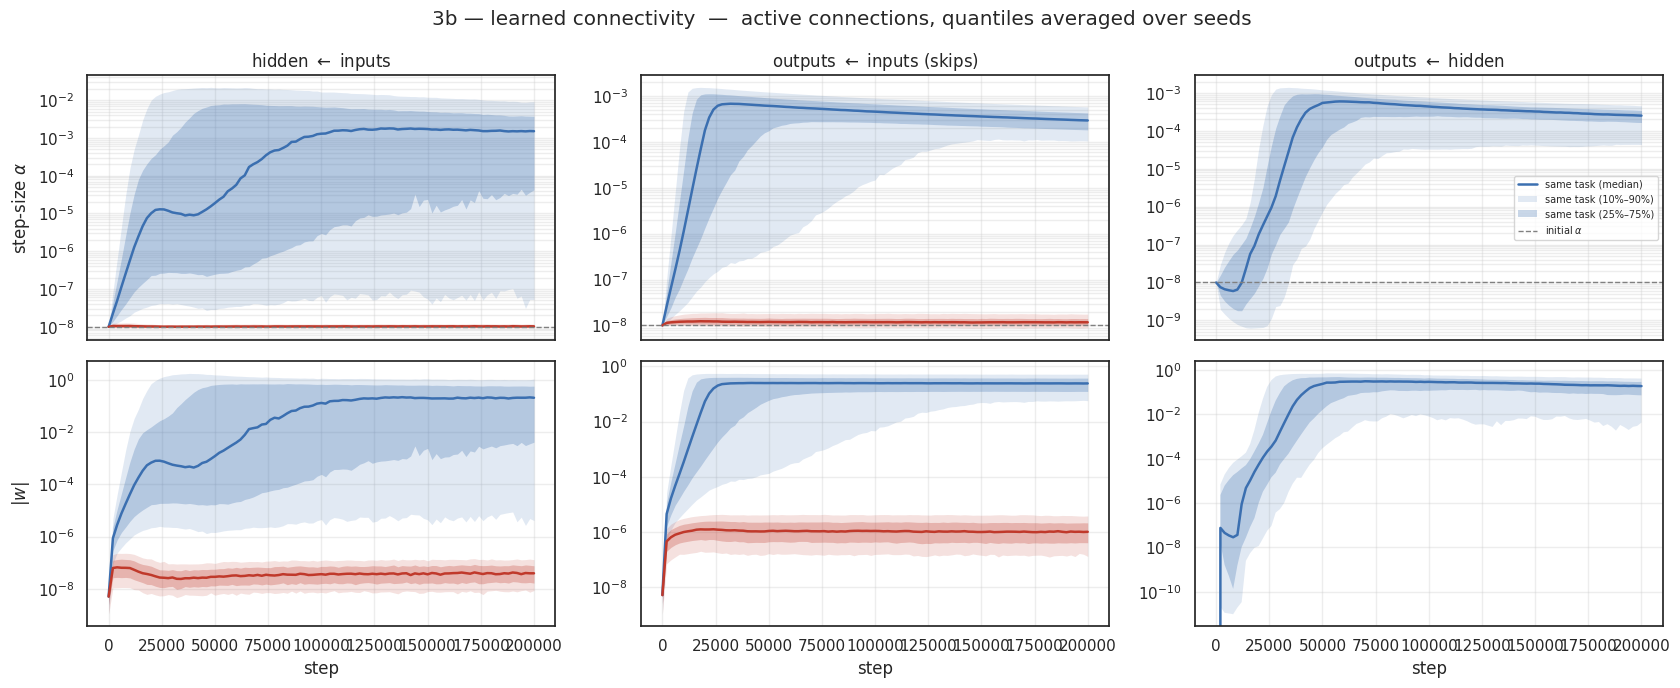

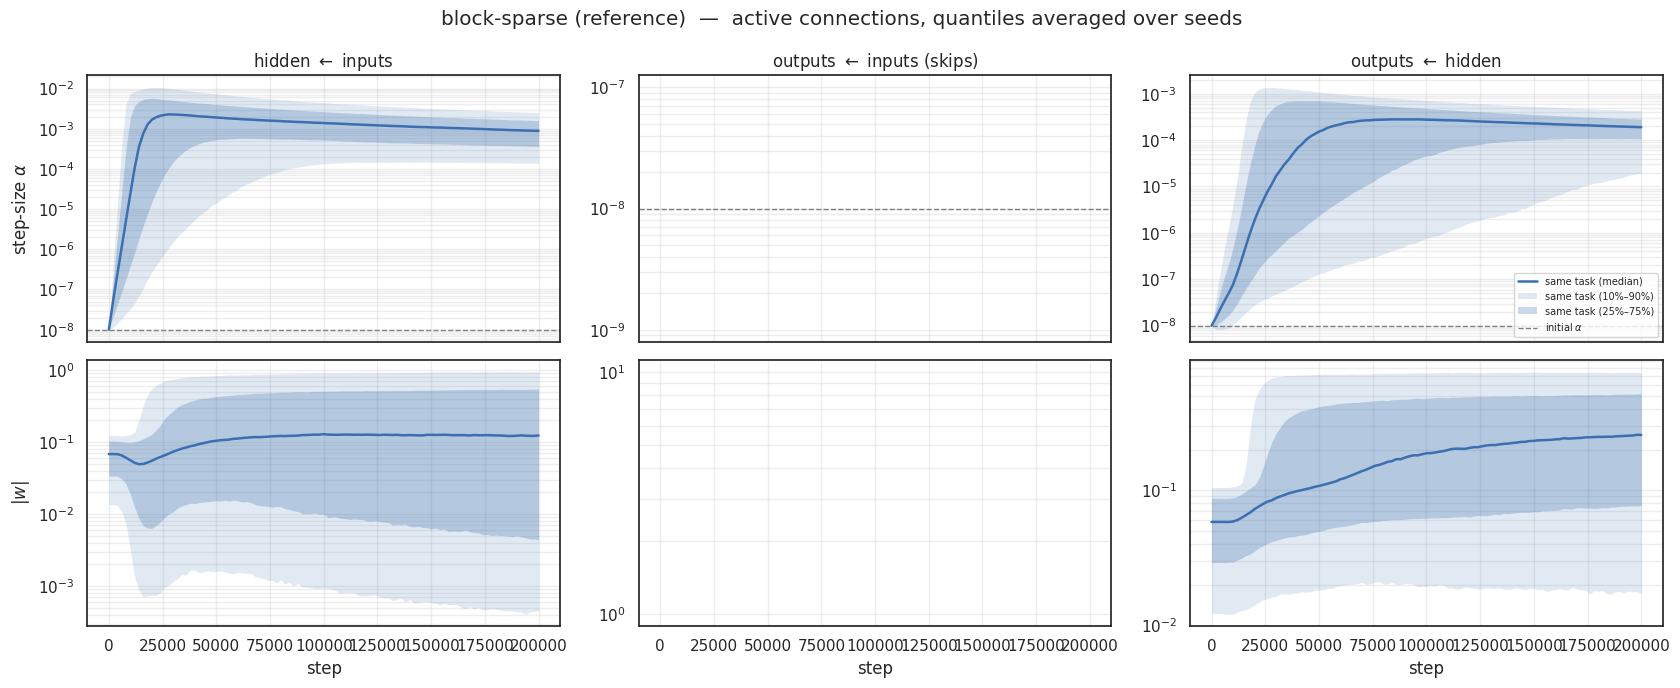

In [9]:
def plot_group_bands(res, title):
    """Median and inter-quantile bands of the step-size and |w| of the active connections, per kind."""
    rows = [('alpha_q', 'step-size $\\alpha$'), ('absw_q', '$|w|$')]
    fig, axes = plt.subplots(len(rows), len(VIEW_NAMES), figsize=(17, 7), sharex=True)
    mid = len(QUANTILES) // 2
    for row, (key, ylabel) in enumerate(rows):
        with warnings.catch_warnings():                     # a group with no connections is all NaN
            warnings.simplefilter('ignore', RuntimeWarning)
            q = np.nanmean(np.asarray(res[key], dtype=np.float64), axis=0)   # (snapshot, view, group, q)
        for col, layer_name in enumerate(VIEW_NAMES):
            ax = axes[row, col]
            for group, (name, color) in enumerate(zip(GROUP_NAMES, GROUP_COLORS)):
                curves = q[:, col, group, :]
                if not np.isfinite(curves).any():
                    continue
                ax.plot(res['snap_steps'], curves[:, mid], color=color, lw=1.8,
                        label=f'{name} (median)')
                for depth, (lo, hi) in enumerate(zip(range(mid), range(len(QUANTILES) - 1, mid, -1))):
                    ax.fill_between(res['snap_steps'], curves[:, lo], curves[:, hi], color=color,
                                    lw=0, alpha=0.15 + 0.12 * depth,
                                    label=f'{name} ({QUANTILES[lo]:.0%}–{QUANTILES[hi]:.0%})')
            ax.set_yscale('log')
            if key == 'alpha_q':
                ax.axhline(INIT_LR, ls='--', c='gray', lw=1, label='initial $\\alpha$')
            ax.grid(alpha=0.35, which='both')
            ax.set_title(layer_name if row == 0 else '')
            ax.set_xlabel('step' if row == len(rows) - 1 else '')
            ax.set_ylabel(ylabel if col == 0 else '')
    axes[0, -1].legend(fontsize=7)
    fig.suptitle(f'{title}  —  active connections, quantiles averaged over seeds')
    fig.tight_layout()
    plt.show()


for label in ('3a — fixed connectivity', '3b — learned connectivity', 'block-sparse (reference)'):
    plot_group_bands(runs[label], label)

### Turnover

How many input connections change sign per step, split by group. In 3b every sign change is a prune
and a regeneration, so this is the rate at which the structure is being recycled: a rate that never
falls means connections are replaced faster than they can prove themselves. In 3a the same events
are counted but nothing is pruned, which shows what the prune rule *would* have done to a fixed
structure.

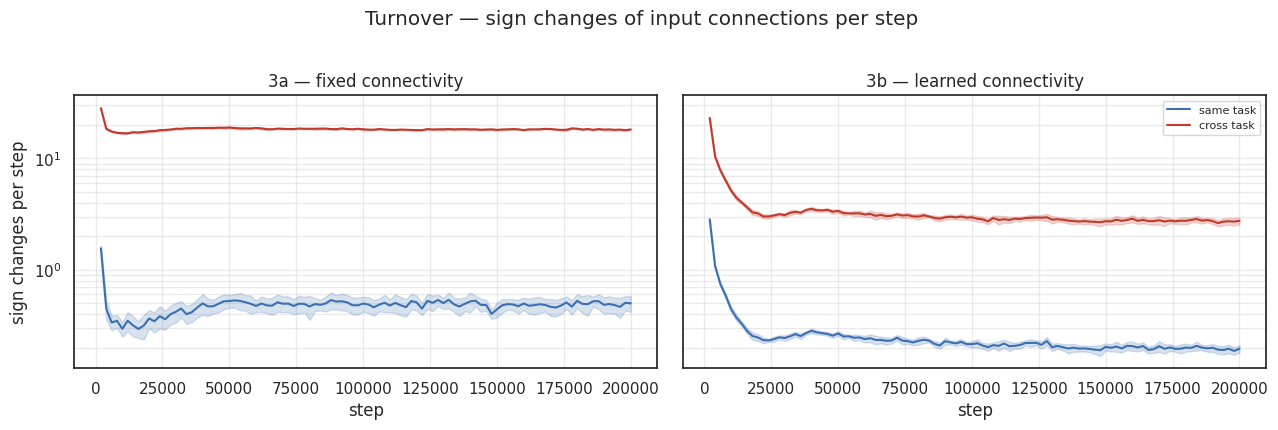

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, label in zip(axes, ('3a — fixed connectivity', '3b — learned connectivity')):
    res = runs[label]
    for key, name, color in (('n_crossed_useful', GROUP_NAMES[0], GROUP_COLORS[0]),
                             ('n_crossed_useless', GROUP_NAMES[1], GROUP_COLORS[1])):
        values = np.asarray(res[key], dtype=np.float64)
        mean, sem = values.mean(0), values.std(0) / np.sqrt(N_SEEDS)
        ax.plot(res['steps'], mean, color=color, label=name)
        ax.fill_between(res['steps'], mean - 2 * sem, mean + 2 * sem, color=color, alpha=0.2)
    ax.set_yscale('log')
    ax.set_xlabel('step')
    ax.set_title(label)
    ax.grid(alpha=0.4, which='both')
axes[0].set_ylabel('sign changes per step')
axes[-1].legend(fontsize=8)
fig.suptitle('Turnover — sign changes of input connections per step', y=1.02)
fig.tight_layout()
plt.show()

### Summary

Everything over the final 10% of the run.

In [11]:
rows = []
for label, res in runs.items():
    mse = final(res, 'mse')
    rows.append({'run': label, 'MSE': mse, 'FVE': 1.0 - (mse - IRREDUCIBLE_MSE),
                 'conn. sep.': final(res, 'connectivity_separation'),
                 'signal sep.': final(res, 'signal_separation'),
                 'purity': final(res, 'hidden_input_purity'),
                 'in/hidden': final(res, 'hidden_incoming'),
                 'out/hidden': final(res, 'hidden_outgoing'),
                 'in/output': final(res, 'output_incoming'),
                 'dead hidden': final(res, 'dead_hidden_fraction'),
                 'connections': final(res, 'n_connections'),
                 'sign changes/step': final(res, 'n_crossed'),
                 'pruned/step': final(res, 'n_pruned')})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f'{v:.4g}'))

                                           run   MSE     FVE  conn. sep.  signal sep.  purity  in/hidden  out/hidden  in/output  dead hidden  connections  sign changes/step  pruned/step
                      block-sparse (reference) 1.394  0.6059           1            1       1         20          10          8            0         1920              16.24            0
                             dense (reference) 1.699  0.3012       0.125       0.6417   0.125        160          80          8            0         1920              7.501            0
               block-sparse linear (reference) 1.359  0.6408           1            1     NaN          0           0         20            1         1600             0.8605            0
                       3a — fixed connectivity 1.904 0.09592      0.1245       0.9075  0.2786       12.9           1      13.68            0         1920              18.67            0
                     3b — learned connectivity 1.374  0.6264      0.77

### 3c — fixed in-degree, feedback first, then backpropagation

3c differs from 3b in where a replacement goes: on the unit that just lost the connection, with a new
random source, so every hidden and output unit keeps its initial number of incoming connections and
the budget cannot drift between units or between kinds of connection. For the first `FEEDBACK_STEPS`
steps the error still comes through the fixed feedback. After that the hidden units' error comes
through the actual hidden→output weights, an output unit's replacement may draw a hidden unit as its
source, and those generated hidden→output connections are pruned on a sign change like any input
connection. Each hidden unit's initial output connection stays protected, so no hidden unit ever
loses its task. The questions: does the switch cost anything (the learning curve against 3b); do
output units take on extra hidden sources, and do the cross-task ones get pruned again (outgoing
connections per hidden unit, and the hidden→output sign changes); and do the hidden→output step-sizes
and weights separate by group the way the input connections do (the third column of the bands).

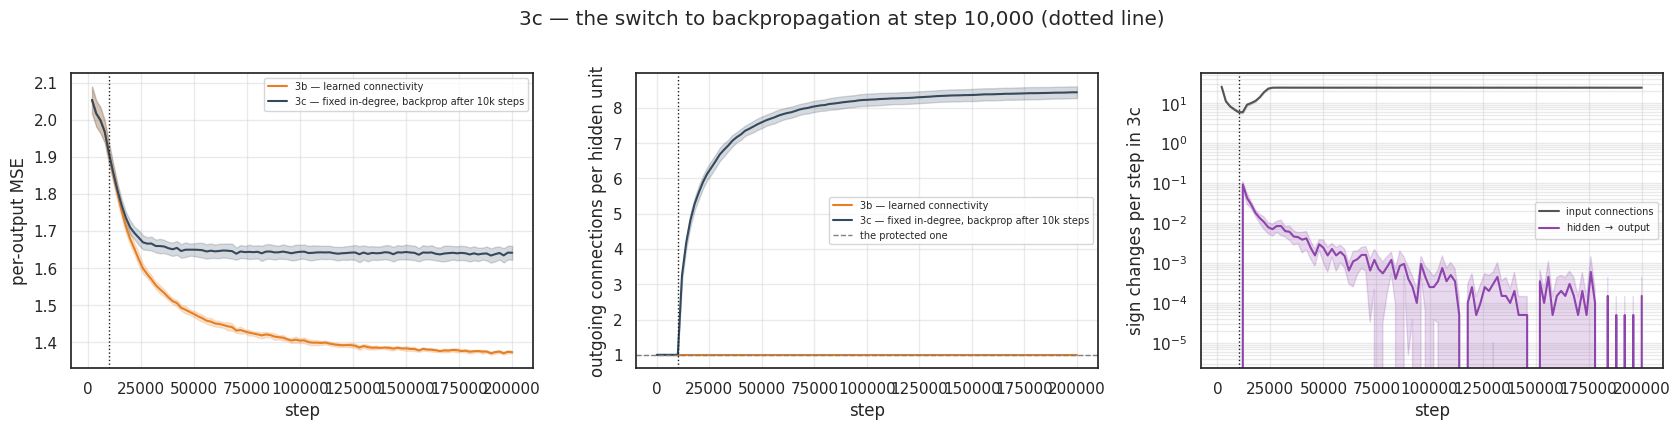

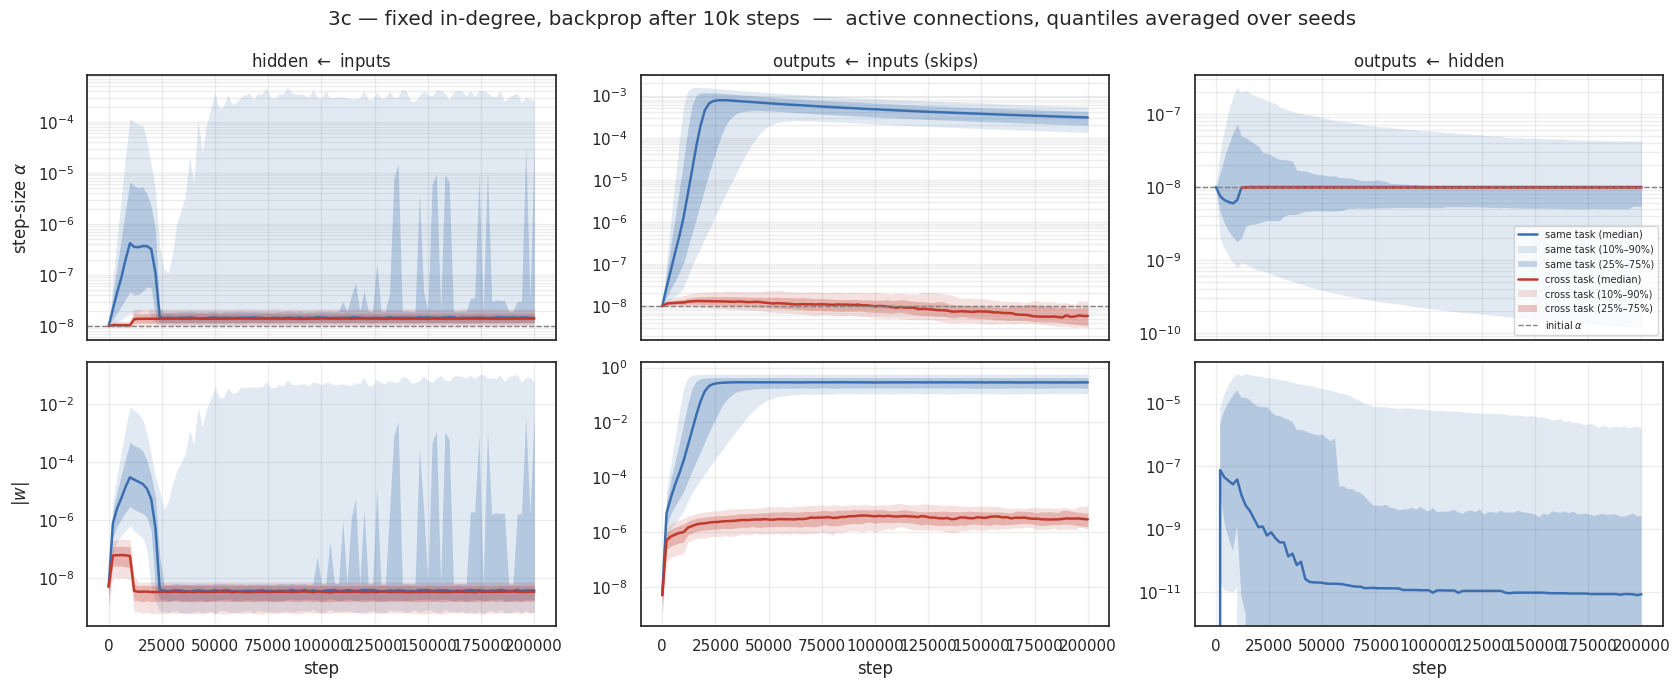

In [12]:
pair = {label: runs[label] for label in ('3b — learned connectivity', LABEL_3C)}
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
for label, res in pair.items():
    mean, sem = res['mse'].mean(0), res['mse'].std(0) / np.sqrt(N_SEEDS)
    axes[0].plot(res['steps'], mean, color=COLORS[label], label=label)
    axes[0].fill_between(res['steps'], mean - 2 * sem, mean + 2 * sem, color=COLORS[label], alpha=0.2)
axes[0].set_xlabel('step')
axes[0].set_ylabel('per-output MSE')
axes[0].grid(alpha=0.4)
axes[0].legend(fontsize=7)

plot_snapshot_metric(pair, 'hidden_outgoing', 'outgoing connections per hidden unit', axes[1],
                     hline=1.0, hline_label='the protected one')
axes[1].legend(fontsize=7)

res = runs[LABEL_3C]
kinds = ((np.asarray(res['n_crossed'] - res['n_crossed_hidden_out'], dtype=np.float64),
          'input connections', '#555555'),
         (np.asarray(res['n_crossed_hidden_out'], dtype=np.float64),
          'hidden $\\rightarrow$ output', '#8e44ad'))
for values, name, color in kinds:
    mean, sem = values.mean(0), values.std(0) / np.sqrt(N_SEEDS)
    axes[2].plot(res['steps'], mean, color=color, label=name)
    axes[2].fill_between(res['steps'], mean - 2 * sem, mean + 2 * sem, color=color, alpha=0.2)
axes[2].set_yscale('log')
axes[2].set_xlabel('step')
axes[2].set_ylabel('sign changes per step in 3c')
axes[2].grid(alpha=0.4, which='both')
axes[2].legend(fontsize=7)

for ax in axes:
    ax.axvline(FEEDBACK_STEPS, ls=':', c='k', lw=1)
fig.suptitle(f'3c — the switch to backpropagation at step {FEEDBACK_STEPS:,} (dotted line)', y=1.02)
fig.tight_layout()
plt.show()

plot_group_bands(runs[LABEL_3C], LABEL_3C)